<a href="https://www.kaggle.com/code/sonawanelalitsunil/airbnb-hotel-insights-eda-85-51?scriptVersionId=266503009" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/airbnb-site-hotel/Airbnb_site_hotel new.csv


## Title: Airbnb Hotel Insights

## Description:
This project analyzes data from Airbnb hotel listings to uncover trends in pricing, location, and guest preferences. It explores key factors that influence booking decisions, such as property type, host ratings, amenities, and neighborhood popularity. Visualizations highlight market patterns, helping hosts and travelers understand the competitive landscape and optimize listings for better performance.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/airbnb-site-hotel/Airbnb_site_hotel new.csv")

In [3]:
df.head()

,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
0,1,Beautiful Victorian Home,1368256,Robert,Toronto,250,0.0,0,4563,1.0,...,47,6,"1,5",2,3,1,"0,9","0,42",102,North America
1,2,"World Class @ CN Tower, convention centre, The...",113345,Adela,Toronto,152,0.0,0,5120,1.0,...,42,4,1,1,2,5,"0,9","0,42",166,North America
2,3,Furnished room in lovely Annex house June -Oct31,1466410,Susan,Toronto,120,0.0,0,4534,1.0,...,0,1,1,1,2,2,1,"0,65",181,North America
3,4,Executive Studio Unit- Ideal for One Person,118124,Brent,Toronto,75,1.0,1,5111,1.0,...,29,1,1,0,1,1,1,1,365,North America
4,5,"Bright Beaches Apt, close to everything",175687,John,Toronto,90,0.0,0,5033,1.0,...,7,2,1,1,1,4,1,"0,8",328,North America


In [4]:
df.tail()

,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
86181,86182,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"87,5",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",273,Asia
86182,86183,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,330402207,葦靜,taipei,25,1.0,0,1559,1.0,...,0,1,0,0,1,34,1,"0,88",96,Asia
86183,86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"89,28125",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",274,Asia
86184,86185,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"100,90625",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",274,Asia
86185,86186,Rental unit in 江山里 · ★New · 1 bedroom · 2 beds...,413599737,迪,taipei,"112,5",1.0,0,1018,1.0,...,0,3,0,0,2,56,"0,99","0,99",274,Asia


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86186 entries, 0 to 86185
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         86186 non-null  int64  
 1   name                       86186 non-null  object 
 2   host_id                    86186 non-null  int64  
 3   host_name                  86186 non-null  object 
 4   city                       86186 non-null  object 
 5   price                      80762 non-null  object 
 6   reply time                 66867 non-null  float64
 7   guest favourite            86186 non-null  int64  
 8   host since                 86186 non-null  int64  
 9   host Certification         82903 non-null  float64
 10  room_type                  86186 non-null  int64  
 11  host total listings count  86186 non-null  int64  
 12  consumer                   35421 non-null  object 
 13  total reviewers number     86186 non-null  int

In [6]:
df.describe()

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
count,86186.000000,8.618600e+04,66867.000000,86186.000000,86186.000000,82903.0,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000
mean,43093.500000,1.959076e+08,0.769857,0.273304,2380.740236,1.0,2.663959,23.492737,36.414174,3.412747,1.247407,1.914441,45.196772,183.385086
std,24879.899487,1.849803e+08,0.420928,0.445658,1269.305372,0.0,0.524877,73.067586,75.989911,2.393287,1.093598,1.732507,258.312637,119.302210
min,1.000000,1.581000e+03,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,21547.250000,2.890381e+07,1.000000,0.000000,1422.000000,1.0,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,80.000000
50%,43093.500000,1.308280e+08,1.000000,0.000000,2540.000000,1.0,3.000000,3.000000,9.000000,2.000000,1.000000,1.000000,3.000000,193.000000
75%,64639.750000,3.492982e+08,1.000000,1.000000,3337.000000,1.0,3.000000,12.000000,37.000000,4.000000,2.000000,2.000000,15.000000,287.000000
max,86186.000000,5.752345e+08,1.000000,1.000000,5745.000000,1.0,4.000000,837.000000,2575.000000,16.000000,21.000000,60.000000,4818.000000,365.000000


In [7]:
df.dtypes

id                             int64
name                          object
host_id                        int64
host_name                     object
city                          object
price                         object
reply time                   float64
guest favourite                int64
host since                     int64
host Certification           float64
room_type                      int64
host total listings count      int64
consumer                      object
total reviewers number         int64
accommodates                   int64
bathrooms                     object
bedrooms                       int64
beds                           int64
listing number                 int64
host response rate            object
host acceptance rate          object
sales                          int64
area                          object
dtype: object

In [8]:
df.shape

(86186, 23)

In [9]:
df.nunique()

id                           86186
name                         76393
host_id                      43957
host_name                    16155
city                            11
price                         9728
reply time                       2
guest favourite                  2
host since                    5038
host Certification               1
room_type                        4
host total listings count      116
consumer                       169
total reviewers number         699
accommodates                    16
bathrooms                       28
bedrooms                        21
beds                            35
listing number                 191
host response rate              93
host acceptance rate           101
sales                          366
area                             3
dtype: int64

In [10]:
df.isnull().sum()

id                               0
name                             0
host_id                          0
host_name                        0
city                             0
price                         5424
reply time                   19319
guest favourite                  0
host since                       0
host Certification            3283
room_type                        0
host total listings count        0
consumer                     50765
total reviewers number           0
accommodates                     0
bathrooms                        0
bedrooms                         0
beds                             0
listing number                   0
host response rate               0
host acceptance rate             0
sales                            0
area                             0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.describe().loc[['min', 'max','mean']]

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
min,1.0,1.581000e+03,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,86186.0,5.752345e+08,1.000000,1.000000,5745.000000,1.0,4.000000,837.000000,2575.000000,16.000000,21.000000,60.000000,4818.000000,365.000000
mean,43093.5,1.959076e+08,0.769857,0.273304,2380.740236,1.0,2.663959,23.492737,36.414174,3.412747,1.247407,1.914441,45.196772,183.385086


In [13]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'city', 'price', 'reply time',
       'guest favourite', 'host since', 'host Certification', 'room_type',
       'host total listings count', 'consumer', 'total reviewers number',
       'accommodates', 'bathrooms', 'bedrooms', 'beds', 'listing number',
       'host response rate', 'host acceptance rate', 'sales', 'area'],
      dtype='object')

## Data visualizations

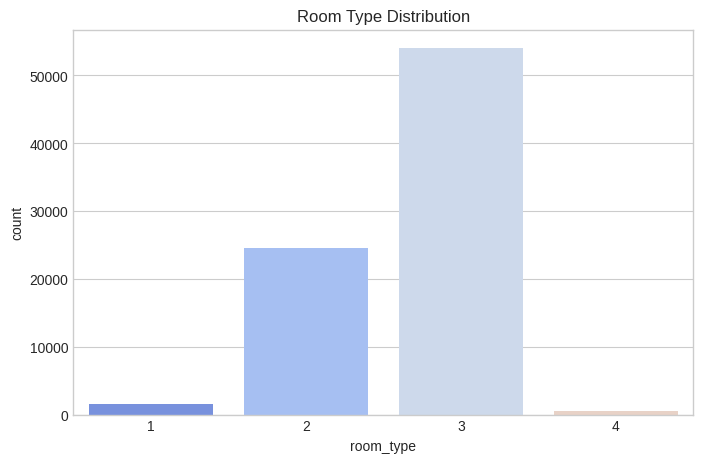

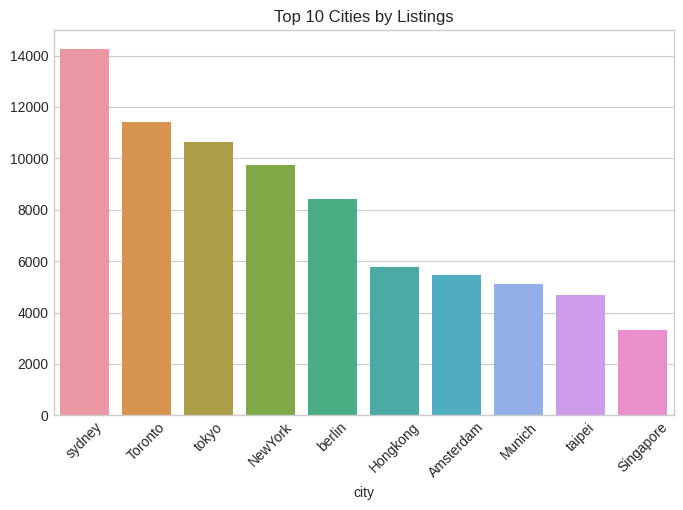

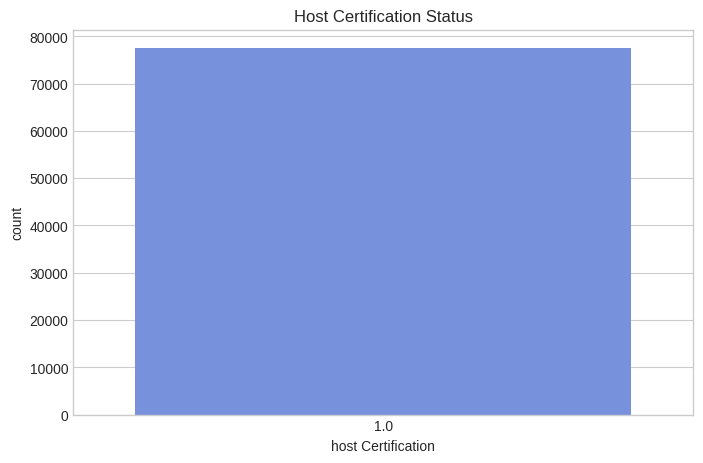

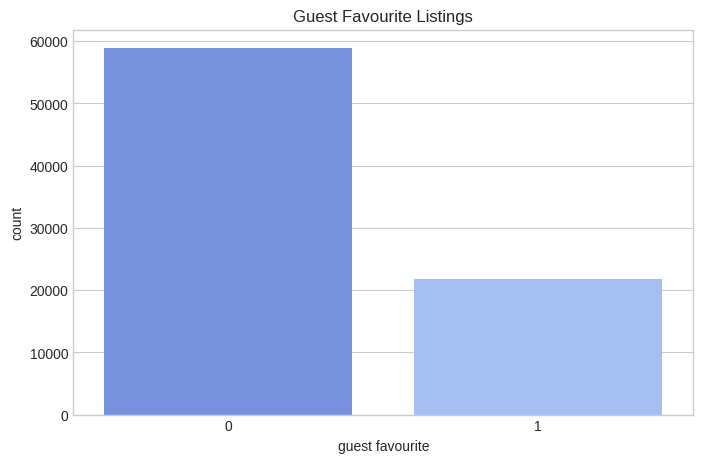

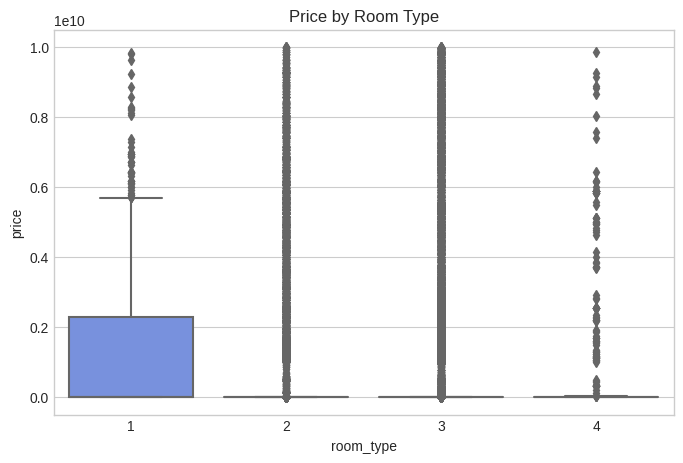

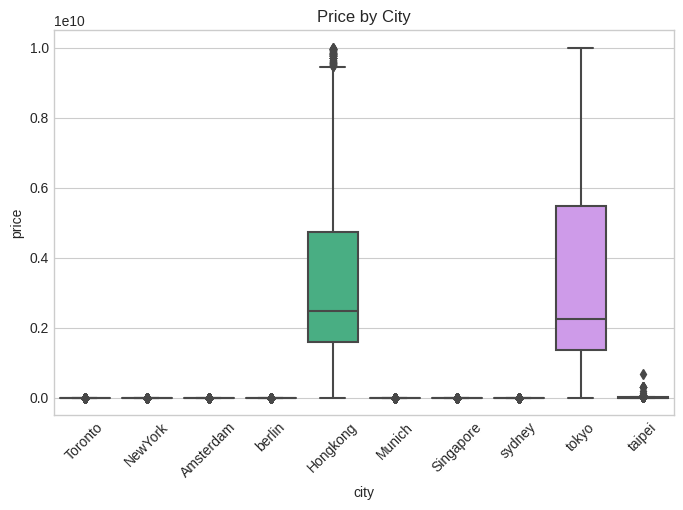

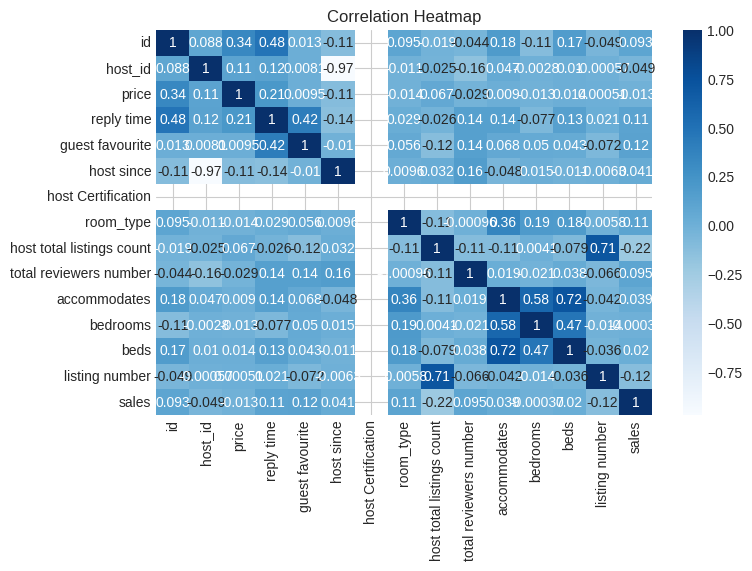

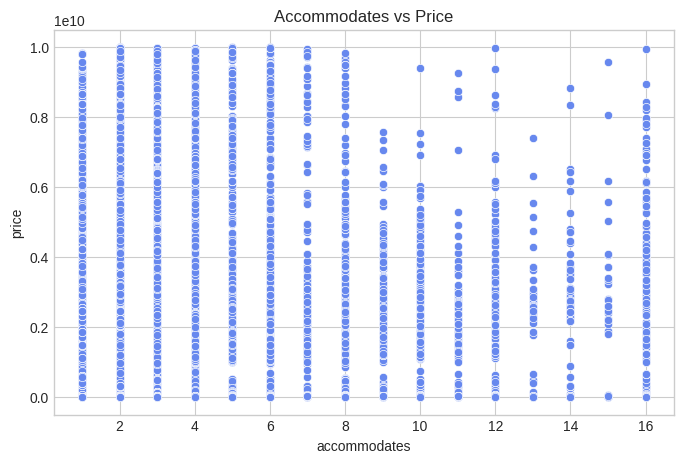

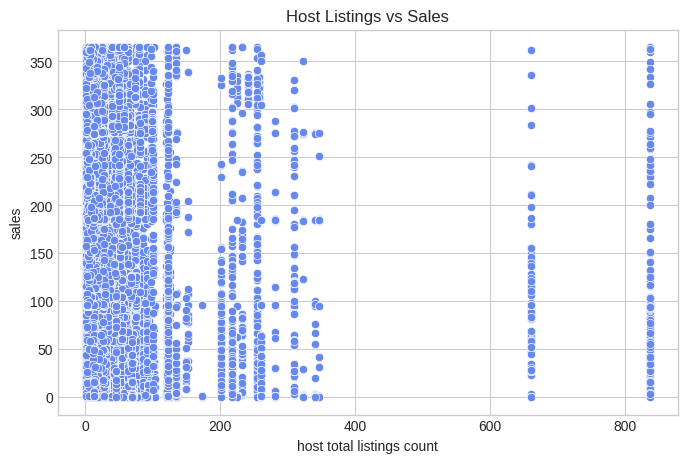

In [14]:
# Clean 'price' column (convert to numeric)
df['price'] = df['price'].astype(str).str.replace('[^0-9.]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Drop rows with missing or invalid prices
df = df.dropna(subset=['price'])

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('coolwarm')
plt.rcParams['figure.figsize'] = (8, 5)

# ==============================
# 1️⃣ Categorical Visualizations
# ==============================

sns.countplot(x='room_type', data=df)
plt.title('Room Type Distribution')
plt.show()

top_cities = df['city'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values)
plt.title('Top 10 Cities by Listings')
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='host Certification', data=df)
plt.title('Host Certification Status')
plt.show()

sns.countplot(x='guest favourite', data=df)
plt.title('Guest Favourite Listings')
plt.show()

# ==============================
# 2️⃣ Price & City Relations
# ==============================

# Price by Room Type
sns.boxplot(x='room_type', y='price', data=df)
plt.title('Price by Room Type')
plt.show()

# Price by Top 10 Cities
top_10 = df['city'].value_counts().nlargest(10).index
sns.boxplot(x='city', y='price', data=df[df['city'].isin(top_10)])
plt.title('Price by City')
plt.xticks(rotation=45)
plt.show()

# ==============================
# 3️⃣ Correlation Heatmap
# ==============================

num_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

# ==============================
# 4️⃣ Scatter Relationships
# ==============================

sns.scatterplot(x='accommodates', y='price', data=df)
plt.title('Accommodates vs Price')
plt.show()

sns.scatterplot(x='host total listings count', y='sales', data=df)
plt.title('Host Listings vs Sales')
plt.show()

## ML Algorithms

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [16]:
df = df.drop(['id', 'name', 'host_id', 'host_name'], axis=1, errors='ignore')

# Fill missing numeric values with median, categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

In [17]:
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print("\nAfter Label Encoding:\n", df.head())


After Label Encoding:
    city  price  reply time  guest favourite  host since  host Certification  \
0     6  250.0         0.0                0        4563                 1.0   
1     6  152.0         0.0                0        5120                 1.0   
2     6  120.0         0.0                0        4534                 1.0   
3     6   75.0         1.0                1        5111                 1.0   
4     6   90.0         0.0                0        5033                 1.0   

   room_type  host total listings count  consumer  total reviewers number  \
0          3                          1       149                      47   
1          3                          5       135                      42   
2          2                          1         0                       0   
3          3                          1       154                      29   
4          3                          1       125                       7   

   accommodates  bathrooms  bedrooms  

In [18]:
target = 'guest favourite'
X = df.drop(target, axis=1)
y = df[target]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (64609, 18)
Test set: (16153, 18)


In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier()
}

accuracy_scores = {}

In [21]:
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracy_scores[name] = acc
    print(f"{name}: {acc:.2f}%")

Logistic Regression: 72.95%
Decision Tree: 81.49%
Random Forest: 85.62%
KNN: 74.62%
SVM: 72.95%
Naive Bayes: 72.95%
Gradient Boosting: 83.38%


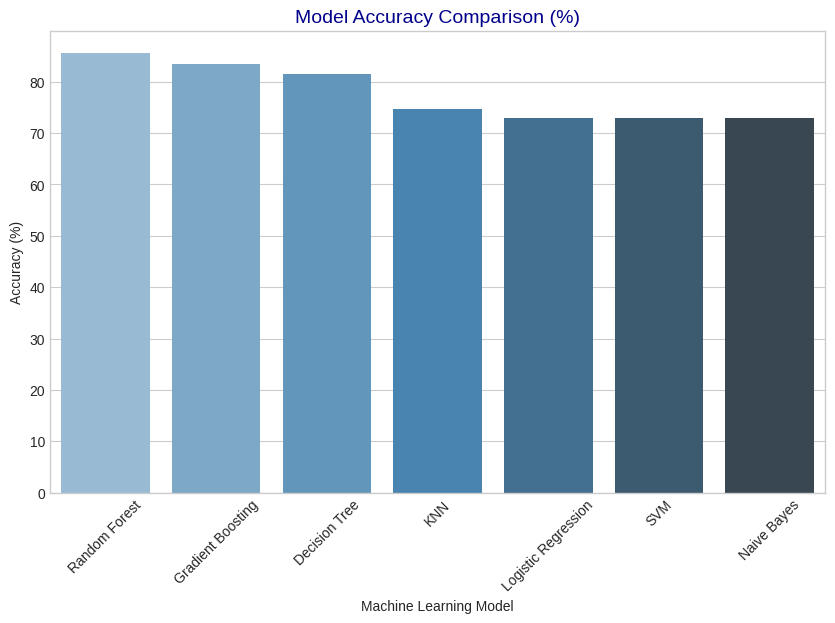

In [22]:
acc_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])
acc_df = acc_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='Blues_d')
plt.title('Model Accuracy Comparison (%)', fontsize=14, color='darkblue')
plt.xticks(rotation=45)
plt.ylabel('Accuracy (%)')
plt.xlabel('Machine Learning Model')
plt.show()

In [23]:
best_model = max(accuracy_scores, key=accuracy_scores.get)
print(f"\n✅ Best Performing Model: {best_model} ({accuracy_scores[best_model]:.2f}%)")


✅ Best Performing Model: Random Forest (85.62%)


## Thank you...pls upvote!!!!